# Anhedonic AI — Combined Analysis
## Experiment 1: Reward-seeking behaviour | Experiment 2: Knowledge integrity
**Model A:** Qwen2-VL-7B, layers 18–27 ablated | ~1,363 neurons | 0.257% of network
- **Exp 1** — Does ablation shift reward choice distribution? (57 MMLU subjects, K=5 folds)
- **Exp 2** — Does ablation damage knowledge? (15 subjects × 3 difficulty tiers, K=5 folds)
- **Stats** — Paired t-tests (one-tailed: H1 = Model A < Baseline), 95% CI, significance stars

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats as sp_stats
from statsmodels.stats.multitest import multipletests
import warnings; warnings.filterwarnings('ignore')
import os
from glob import glob

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.2, 'grid.linewidth': 0.5,
})
BL='#2563EB'; MA='#DC2626'; CH='#9CA3AF'; GR='#16A34A'; OR='#EA580C'
C10='#1D4ED8'; C20='#93C5FD'; C30='#FCA5A5'; C40='#DC2626'
REWARD_LEVELS=[10,20,30,40]; CHANCE_MEAN=25.0; CHANCE_RS=0.25

EXP1_RESULTS = '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/eval4/results'
EXP2_RESULTS = '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/eval4/knowledge_results'

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def add_sig_bracket(ax, x1, x2, y, p, h=0.5, fs=11):
    """Draw a significance bracket between two bars."""
    stars = sig_stars(p)
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
    ax.text((x1+x2)/2, y+h+0.1, stars, ha='center', va='bottom', fontsize=fs,
            color='black' if stars != 'ns' else CH)

# ── Load Exp1 ─────────────────────────────────────────────────────────────
e1_summary = pd.read_csv(f'{EXP1_RESULTS}/combined_summary.csv')
e1_b = e1_summary[e1_summary['tier']=='baseline'].copy()
e1_a = e1_summary[e1_summary['tier']=='model_A'].copy()

def get_chosen_reward(row):
    try:
        c = int(float(row['Chosen_Option']))
        if 1 <= c <= 4:
            return int(row[f'pts_pos{c}'])
    except: pass
    return np.nan

raw_parts = []
for p in glob(f'{EXP1_RESULTS}/*/detailed_results.csv'):
    raw_parts.append(pd.read_csv(p))
e1_raw = pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame()
if not e1_raw.empty:
    e1_raw = e1_raw[e1_raw['Is_Multi_Answer'] == False].copy()
    e1_raw['chosen_reward'] = e1_raw.apply(get_chosen_reward, axis=1)
    e1_raw['tier'] = e1_raw['tier'].str.strip()

# ── Load Exp2 ─────────────────────────────────────────────────────────────
e2_summary = pd.read_csv(f'{EXP2_RESULTS}/combined_summary.csv')
e2_b = e2_summary[e2_summary['tier']=='baseline'].copy()
e2_a = e2_summary[e2_summary['tier']=='model_A'].copy()

e2_sub_parts = []
for p in glob(f'{EXP2_RESULTS}/*/subset_stats.csv'):
    e2_sub_parts.append(pd.read_csv(p))
e2_subsets = pd.concat(e2_sub_parts, ignore_index=True) if e2_sub_parts else pd.DataFrame()

# ── Load Exp1 subset stats ────────────────────────────────────────────────
e1_sub_parts = []
for p in glob(f'{EXP1_RESULTS}/*/subset_stats.csv'):
    e1_sub_parts.append(pd.read_csv(p))
e1_subsets = pd.concat(e1_sub_parts, ignore_index=True) if e1_sub_parts else pd.DataFrame()

print(f'Exp1: {e1_summary["subject"].nunique()} subjects | Exp2: {e2_summary["subject"].nunique()} subjects')
print(f'Exp1 raw rows: {len(e1_raw)} | parsed reward: {e1_raw["chosen_reward"].notna().sum()}')

Exp1: 57 subjects | Exp2: 30 subjects
Exp1 raw rows: 10391 | parsed reward: 10391


## Stats Cell — All Paired T-Tests (run this first, used by all plots)

In [3]:
# ══ PAIRED T-TESTS ═════════════════════════════════════════════════════════
# Paired = one measurement per subject for each tier
# One-tailed (alternative='less'): H1 = Model A < Baseline
# This is correct — hypothesis is DIRECTIONAL (ablation reduces reward-seeking)

common1 = e1_b.set_index('subject').index.intersection(e1_a.set_index('subject').index)
b_pts   = e1_b.set_index('subject').loc[common1,'mean_pts_mean'].values
a_pts   = e1_a.set_index('subject').loc[common1,'mean_pts_mean'].values
b_40    = e1_b.set_index('subject').loc[common1,'rate_40pt_mean'].values
a_40    = e1_a.set_index('subject').loc[common1,'rate_40pt_mean'].values

delta_pts = a_pts - b_pts
delta_40  = a_40  - b_40

t_pts1,  p_pts1  = sp_stats.ttest_rel(a_pts, b_pts, alternative='less')
t_pts2,  p_pts2  = sp_stats.ttest_rel(a_pts, b_pts, alternative='two-sided')
t_40_1,  p_40_1  = sp_stats.ttest_rel(a_40,  b_40,  alternative='less')
t_40_2,  p_40_2  = sp_stats.ttest_rel(a_40,  b_40,  alternative='two-sided')

ci_pts = sp_stats.t.interval(0.95, len(delta_pts)-1,
                              loc=delta_pts.mean(), scale=sp_stats.sem(delta_pts))
ci_40  = sp_stats.t.interval(0.95, len(delta_40)-1,
                              loc=delta_40.mean(),  scale=sp_stats.sem(delta_40))

common2  = e2_b.set_index('subject').index.intersection(e2_a.set_index('subject').index)
b_acc    = e2_b.set_index('subject').loc[common2,'acc_%_mean'].values
a_acc    = e2_a.set_index('subject').loc[common2,'acc_%_mean'].values
delta_acc = a_acc - b_acc
t_acc1,  p_acc1  = sp_stats.ttest_rel(a_acc, b_acc, alternative='less')
t_acc2,  p_acc2  = sp_stats.ttest_rel(a_acc, b_acc, alternative='two-sided')
ci_acc   = sp_stats.t.interval(0.95, len(delta_acc)-1,
                                loc=delta_acc.mean(), scale=sp_stats.sem(delta_acc))

print('=' * 65)
print('PAIRED T-TEST RESULTS (one-tailed H1: Model A < Baseline)')
print('=' * 65)
print(f'\nExp1 — Mean pts chosen:')
print(f'  N={len(common1)}  Mean Δ={delta_pts.mean():+.3f}  95%CI=[{ci_pts[0]:.3f},{ci_pts[1]:.3f}]')
print(f'  One-tailed:  t={t_pts1:.3f}  p={p_pts1:.4f}  {sig_stars(p_pts1)}')
print(f'  Two-tailed:  t={t_pts2:.3f}  p={p_pts2:.4f}  {sig_stars(p_pts2)}')
print(f'\nExp1 — 40pt choice rate:')
print(f'  N={len(common1)}  Mean Δ={delta_40.mean()*100:+.2f}pp  95%CI=[{ci_40[0]*100:.2f},{ci_40[1]*100:.2f}]pp')
print(f'  One-tailed:  t={t_40_1:.3f}  p={p_40_1:.4f}  {sig_stars(p_40_1)}')
print(f'  Two-tailed:  t={t_40_2:.3f}  p={p_40_2:.4f}  {sig_stars(p_40_2)}')
print(f'\nExp2 — Knowledge accuracy:')
print(f'  N={len(common2)}  Mean Δ={delta_acc.mean():+.3f}pp  95%CI=[{ci_acc[0]:.2f},{ci_acc[1]:.2f}]pp')
print(f'  One-tailed:  t={t_acc1:.3f}  p={p_acc1:.4f}  {sig_stars(p_acc1)}')
print(f'  Two-tailed:  t={t_acc2:.3f}  p={p_acc2:.4f}  {sig_stars(p_acc2)}')
print(f'\n{"─"*65}')
print('SUPERVISOR SUMMARY TABLE')
print(f'{"─"*65}')
print(f'  {"Metric":<22} {"Δ":>8}  {"One-tail p":>12}  {"Two-tail p":>12}  {"Sig"}')
print(f'  {"─"*60}')
print(f'  {"Mean pts (Exp1)":<22} {delta_pts.mean():>+8.3f}  {p_pts1:>12.4f}  {p_pts2:>12.4f}  {sig_stars(p_pts1)}')
print(f'  {"40pt rate (Exp1)":<22} {delta_40.mean()*100:>+7.2f}pp  {p_40_1:>12.4f}  {p_40_2:>12.4f}  {sig_stars(p_40_1)}')
print(f'  {"Accuracy (Exp2)":<22} {delta_acc.mean():>+7.2f}pp  {p_acc1:>12.4f}  {p_acc2:>12.4f}  {sig_stars(p_acc1)}')

PAIRED T-TEST RESULTS (one-tailed H1: Model A < Baseline)

Exp1 — Mean pts chosen:
  N=57  Mean Δ=-2.097  95%CI=[-2.775,-1.419]
  One-tailed:  t=-6.194  p=0.0000  ***
  Two-tailed:  t=-6.194  p=0.0000  ***

Exp1 — 40pt choice rate:
  N=57  Mean Δ=-8.72pp  95%CI=[-11.31,-6.14]pp
  One-tailed:  t=-6.760  p=0.0000  ***
  Two-tailed:  t=-6.760  p=0.0000  ***

Exp2 — Knowledge accuracy:
  N=30  Mean Δ=-3.510pp  95%CI=[-5.56,-1.46]pp
  One-tailed:  t=-3.495  p=0.0008  ***
  Two-tailed:  t=-3.495  p=0.0015  **

─────────────────────────────────────────────────────────────────
SUPERVISOR SUMMARY TABLE
─────────────────────────────────────────────────────────────────
  Metric                        Δ    One-tail p    Two-tail p  Sig
  ────────────────────────────────────────────────────────────
  Mean pts (Exp1)          -2.097        0.0000        0.0000  ***
  40pt rate (Exp1)         -8.72pp        0.0000        0.0000  ***
  Accuracy (Exp2)          -3.51pp        0.0008        0.0015  ***


---
# EXPERIMENT 1 — Reward-Seeking Behaviour

## E1.1 — Overall reward choice distribution + significance

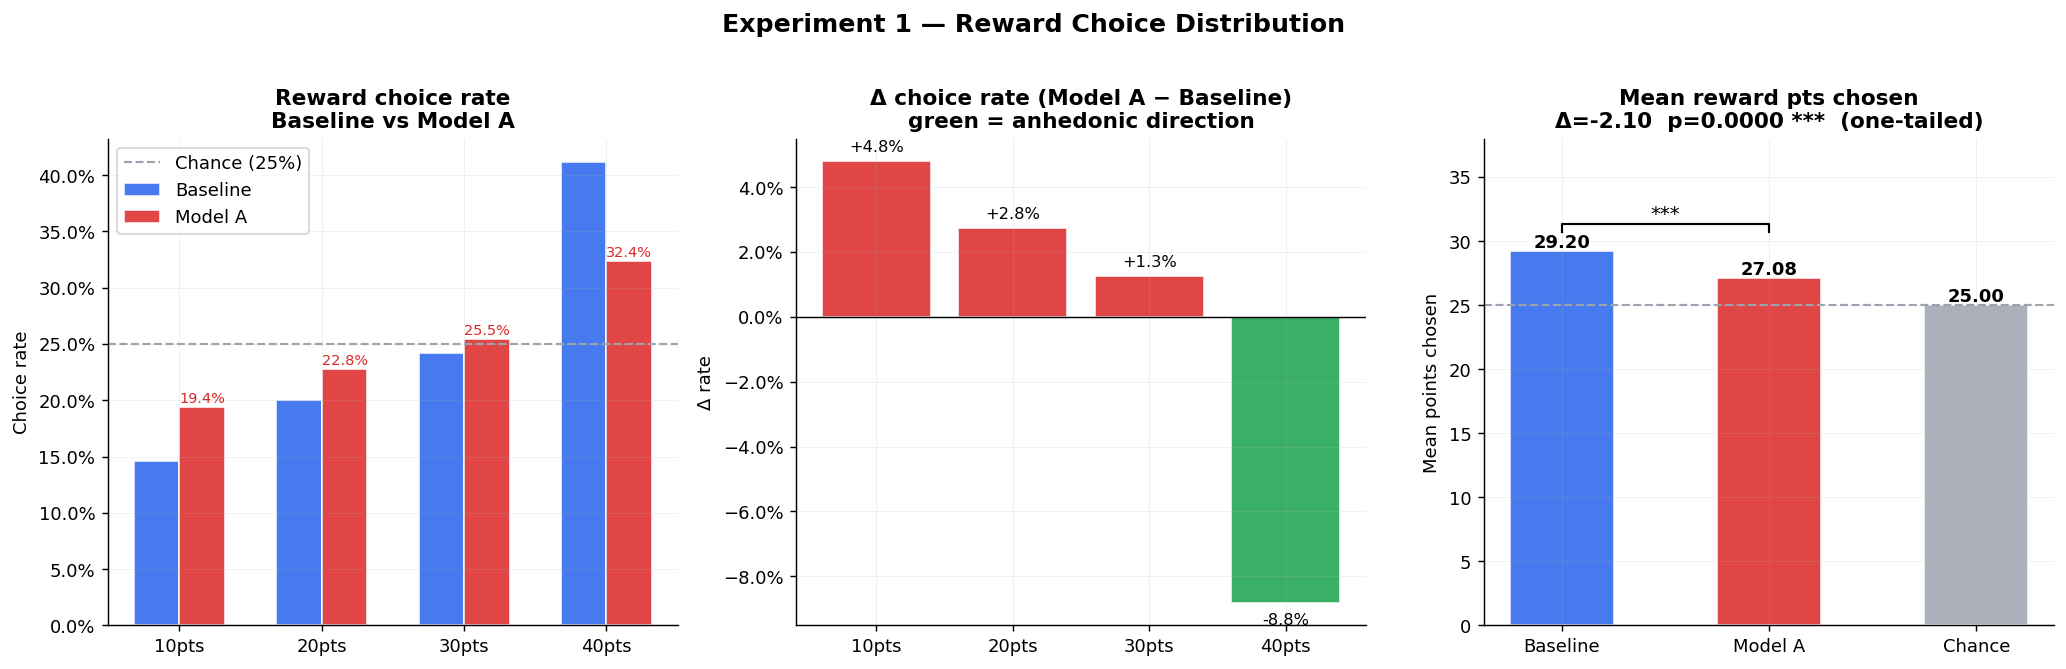

Mean pts: Baseline=29.20  Model A=27.08  Δ=-2.12  p=0.0000 ***


In [4]:
if e1_raw.empty:
    print('No raw Exp1 data')
else:
    valid_b = e1_raw[(e1_raw['tier']=='baseline') & e1_raw['chosen_reward'].notna()]['chosen_reward']
    valid_a = e1_raw[(e1_raw['tier']=='model_A')  & e1_raw['chosen_reward'].notna()]['chosen_reward']
    dist_b  = {r: (valid_b==r).mean() for r in REWARD_LEVELS}
    dist_a  = {r: (valid_a==r).mean() for r in REWARD_LEVELS}
    delta   = {r: dist_a[r]-dist_b[r]  for r in REWARD_LEVELS}

    x, w = np.arange(4), 0.32
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Left: choice rates
    ax = axes[0]
    ax.bar(x-w/2, [dist_b[r] for r in REWARD_LEVELS], w, label='Baseline', color=BL, alpha=0.85, edgecolor='white')
    ax.bar(x+w/2, [dist_a[r] for r in REWARD_LEVELS], w, label='Model A',  color=MA, alpha=0.85, edgecolor='white')
    ax.axhline(0.25, color=CH, lw=1.2, ls='--', label='Chance (25%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xticks(x); ax.set_xticklabels([f'{r}pts' for r in REWARD_LEVELS])
    ax.set_title('Reward choice rate\nBaseline vs Model A', fontweight='bold')
    ax.set_ylabel('Choice rate'); ax.legend()
    for i,r in enumerate(REWARD_LEVELS):
        ax.text(i+w/2, dist_a[r]+0.004, f'{dist_a[r]:.1%}', ha='center', fontsize=8, color=MA)

    # Middle: delta
    ax2 = axes[1]
    dcols = [GR if delta[r]<0 else MA for r in REWARD_LEVELS]
    ax2.bar(x, [delta[r] for r in REWARD_LEVELS], color=dcols, alpha=0.85, edgecolor='white')
    ax2.axhline(0, color='black', lw=0.8)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2.set_xticks(x); ax2.set_xticklabels([f'{r}pts' for r in REWARD_LEVELS])
    ax2.set_title('Δ choice rate (Model A − Baseline)\ngreen = anhedonic direction', fontweight='bold')
    ax2.set_ylabel('Δ rate')
    for i,r in enumerate(REWARD_LEVELS):
        ax2.text(i, delta[r]+(0.002 if delta[r]>=0 else -0.003),
                 f'{delta[r]:+.1%}', ha='center', va='bottom' if delta[r]>=0 else 'top', fontsize=9)

    # Right: mean pts + significance bracket + p-value
    ax3 = axes[2]
    means  = [valid_b.mean(), valid_a.mean(), CHANCE_MEAN]
    labels = ['Baseline', 'Model A', 'Chance']
    bars   = ax3.bar(labels, means, color=[BL,MA,CH], alpha=0.85, edgecolor='white', width=0.5)
    ax3.axhline(CHANCE_MEAN, color=CH, lw=1.2, ls='--')
    ax3.set_ylim(0, 38)
    ax3.set_ylabel('Mean points chosen')
    for bar, val in zip(bars, means):
        ax3.text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.2f}',
                 ha='center', fontweight='bold')
    # Significance bracket between Baseline and Model A
    add_sig_bracket(ax3, 0, 1, max(means[:2])+1.5, p_pts1, h=0.6)
    ax3.set_title(f'Mean reward pts chosen\nΔ={delta_pts.mean():+.2f}  p={p_pts1:.4f} {sig_stars(p_pts1)}  (one-tailed)',
                  fontweight='bold')

    plt.suptitle('Experiment 1 — Reward Choice Distribution', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{EXP1_RESULTS}/fig_E1_choice_distribution.png', bbox_inches='tight')
    plt.show()
    print(f'Mean pts: Baseline={valid_b.mean():.2f}  Model A={valid_a.mean():.2f}  Δ={valid_a.mean()-valid_b.mean():+.2f}  p={p_pts1:.4f} {sig_stars(p_pts1)}')

## E1.2 — Per-subject mean pts + error bars (std across K=5 folds)

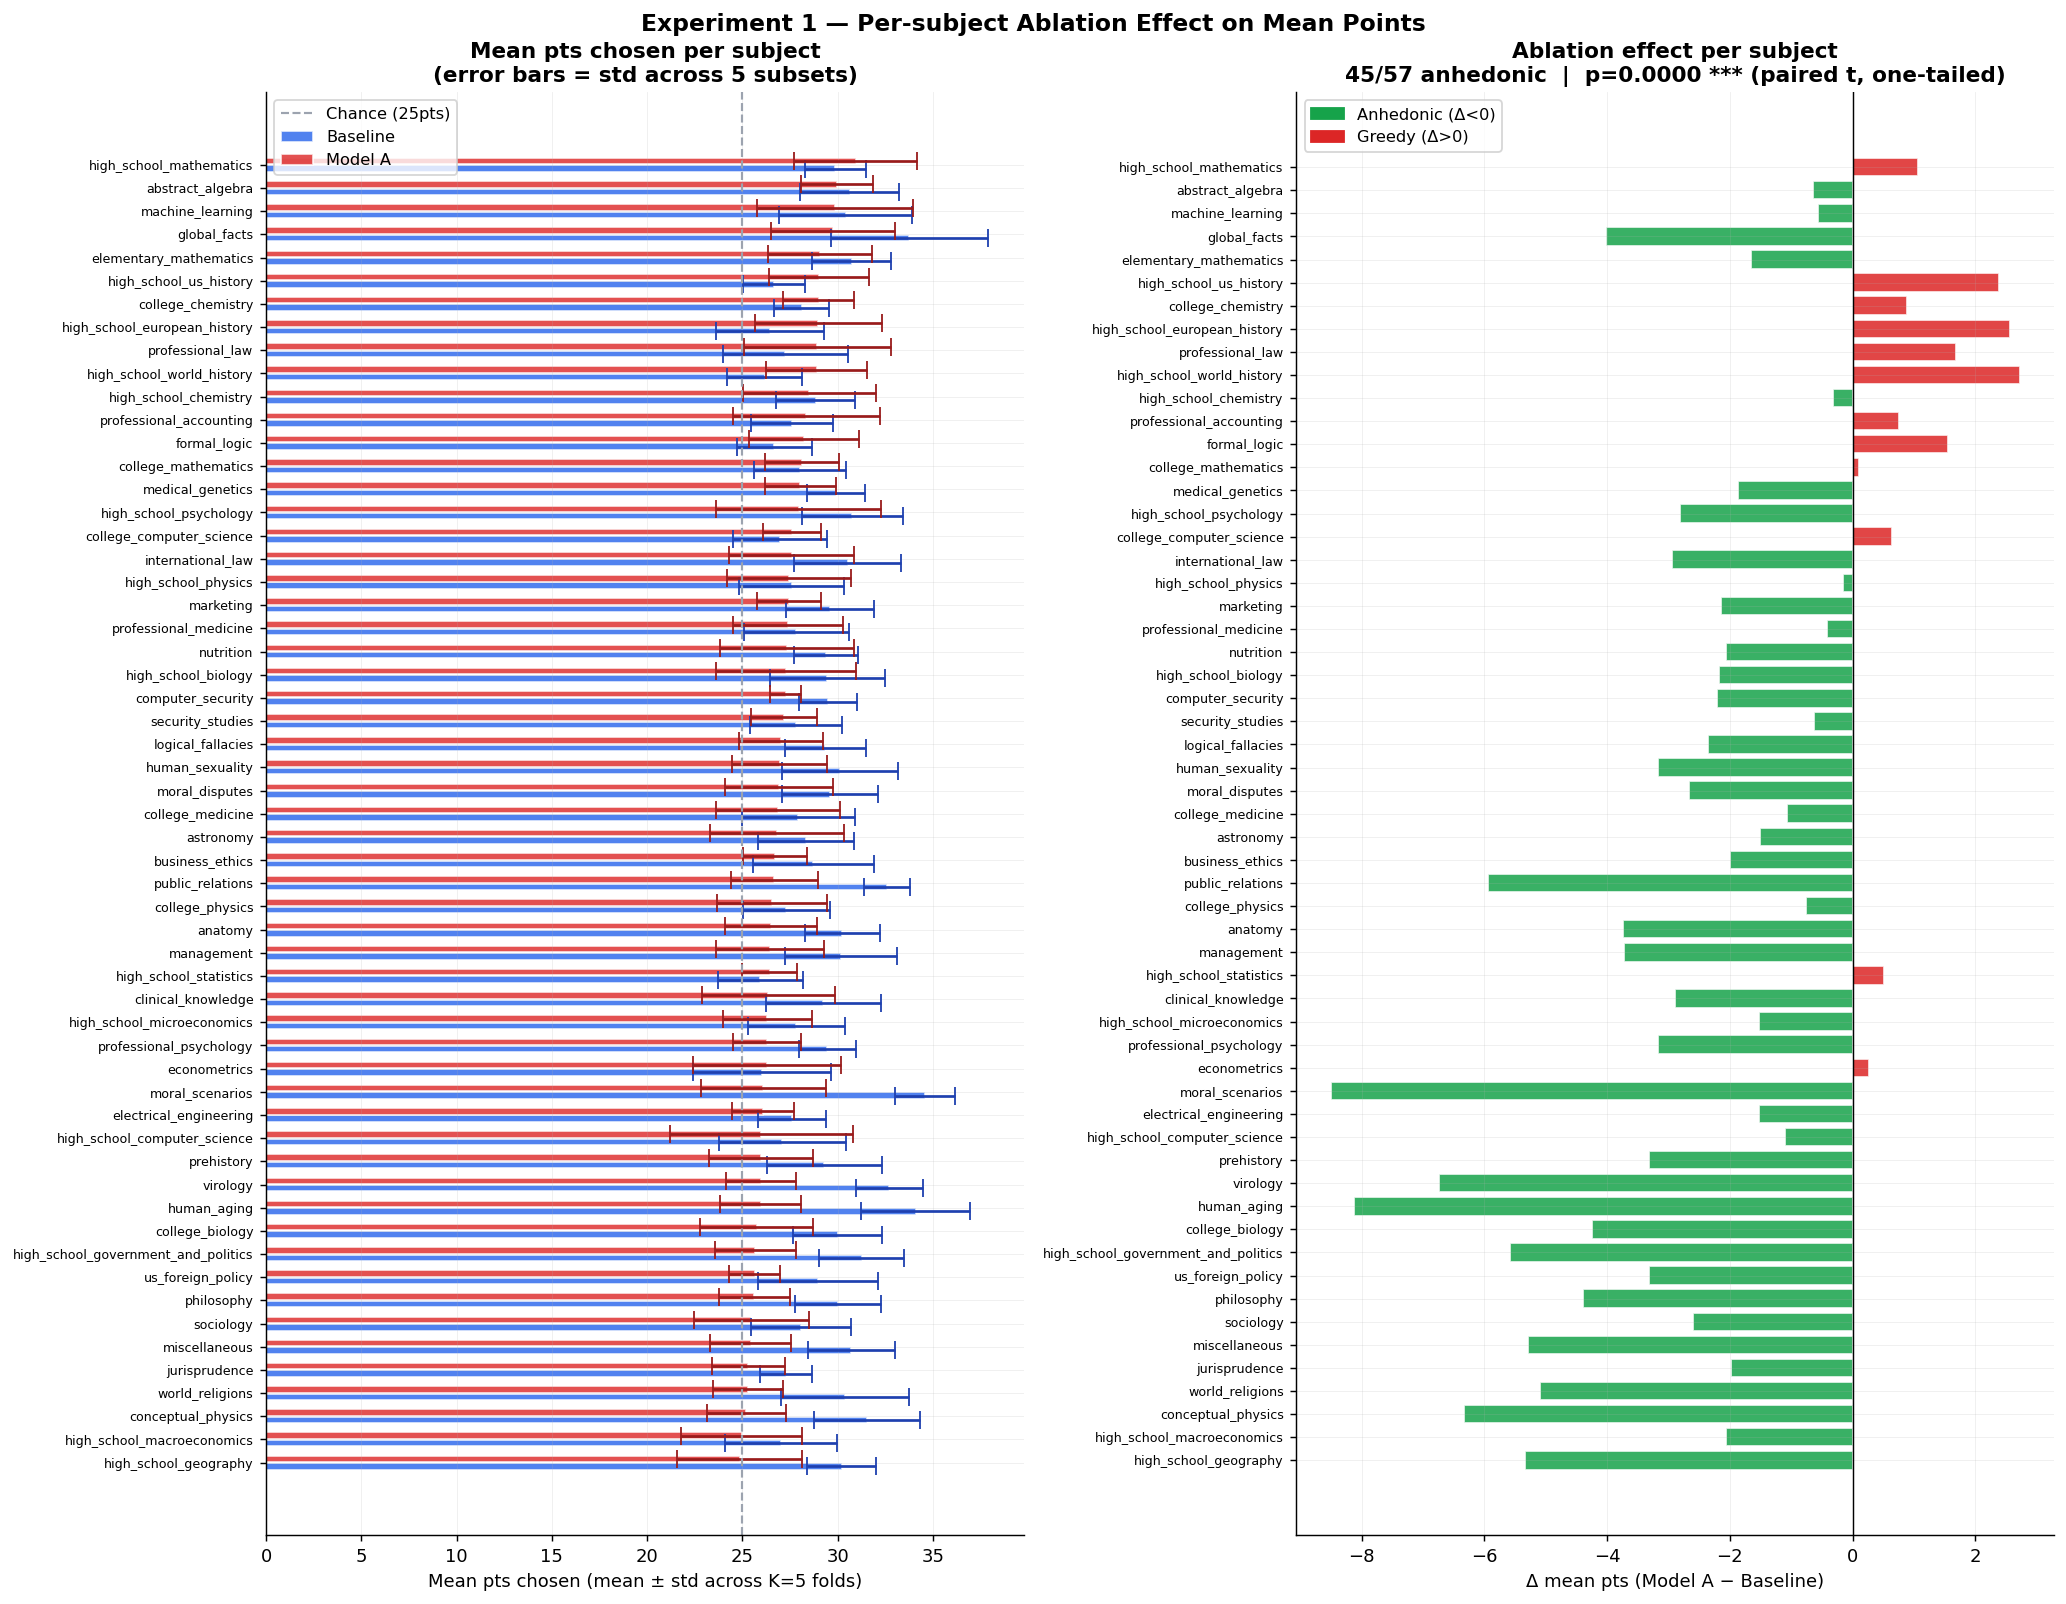

Mean Δ=-2.097  p=0.0000 ***  95%CI=[-2.775,-1.419]


In [5]:
pts_b = e1_b.set_index('subject')[['mean_pts_mean','mean_pts_std']].rename(columns={'mean_pts_mean':'mean','mean_pts_std':'std'})
pts_a = e1_a.set_index('subject')[['mean_pts_mean','mean_pts_std']].rename(columns={'mean_pts_mean':'mean','mean_pts_std':'std'})
pts   = pd.DataFrame({'b_mean':pts_b['mean'],'b_std':pts_b['std'],
                       'a_mean':pts_a['mean'],'a_std':pts_a['std']}).dropna()
pts['delta'] = pts['a_mean'] - pts['b_mean']
pts = pts.sort_values('a_mean')
y = np.arange(len(pts))

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(pts)*0.22)))

ax = axes[0]
ax.barh(y-0.16, pts['b_mean'], 0.28, xerr=pts['b_std'], color=BL, alpha=0.8,
        label='Baseline', edgecolor='white',
        error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#1e40af'})
ax.barh(y+0.16, pts['a_mean'], 0.28, xerr=pts['a_std'], color=MA, alpha=0.8,
        label='Model A', edgecolor='white',
        error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#991b1b'})
ax.axvline(CHANCE_MEAN, color=CH, lw=1.2, ls='--', label='Chance (25pts)')
ax.set_yticks(y); ax.set_yticklabels(pts.index, fontsize=7)
ax.set_xlabel('Mean pts chosen (mean ± std across K=5 folds)')
ax.set_title('Mean pts chosen per subject\n(error bars = std across 5 subsets)', fontweight='bold')
ax.legend(fontsize=9)

ax2 = axes[1]
dcols = [GR if d<0 else MA for d in pts['delta']]
ax2.barh(y, pts['delta'], color=dcols, alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_yticks(y); ax2.set_yticklabels(pts.index, fontsize=7)
ax2.set_xlabel('Δ mean pts (Model A − Baseline)')
n_anhed = (pts['delta']<0).sum()
ax2.set_title(f'Ablation effect per subject\n'
              f'{n_anhed}/{len(pts)} anhedonic  |  p={p_pts1:.4f} {sig_stars(p_pts1)} (paired t, one-tailed)',
              fontweight='bold')
patches = [mpatches.Patch(color=GR,label='Anhedonic (Δ<0)'),
           mpatches.Patch(color=MA,label='Greedy (Δ>0)')]
ax2.legend(handles=patches, fontsize=9)

plt.suptitle('Experiment 1 — Per-subject Ablation Effect on Mean Points', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP1_RESULTS}/fig_E1_per_subject_delta.png', bbox_inches='tight')
plt.show()
print(f'Mean Δ={pts["delta"].mean():+.3f}  p={p_pts1:.4f} {sig_stars(p_pts1)}  95%CI=[{ci_pts[0]:.3f},{ci_pts[1]:.3f}]')

## E1.3 — Stacked choice distribution per subject

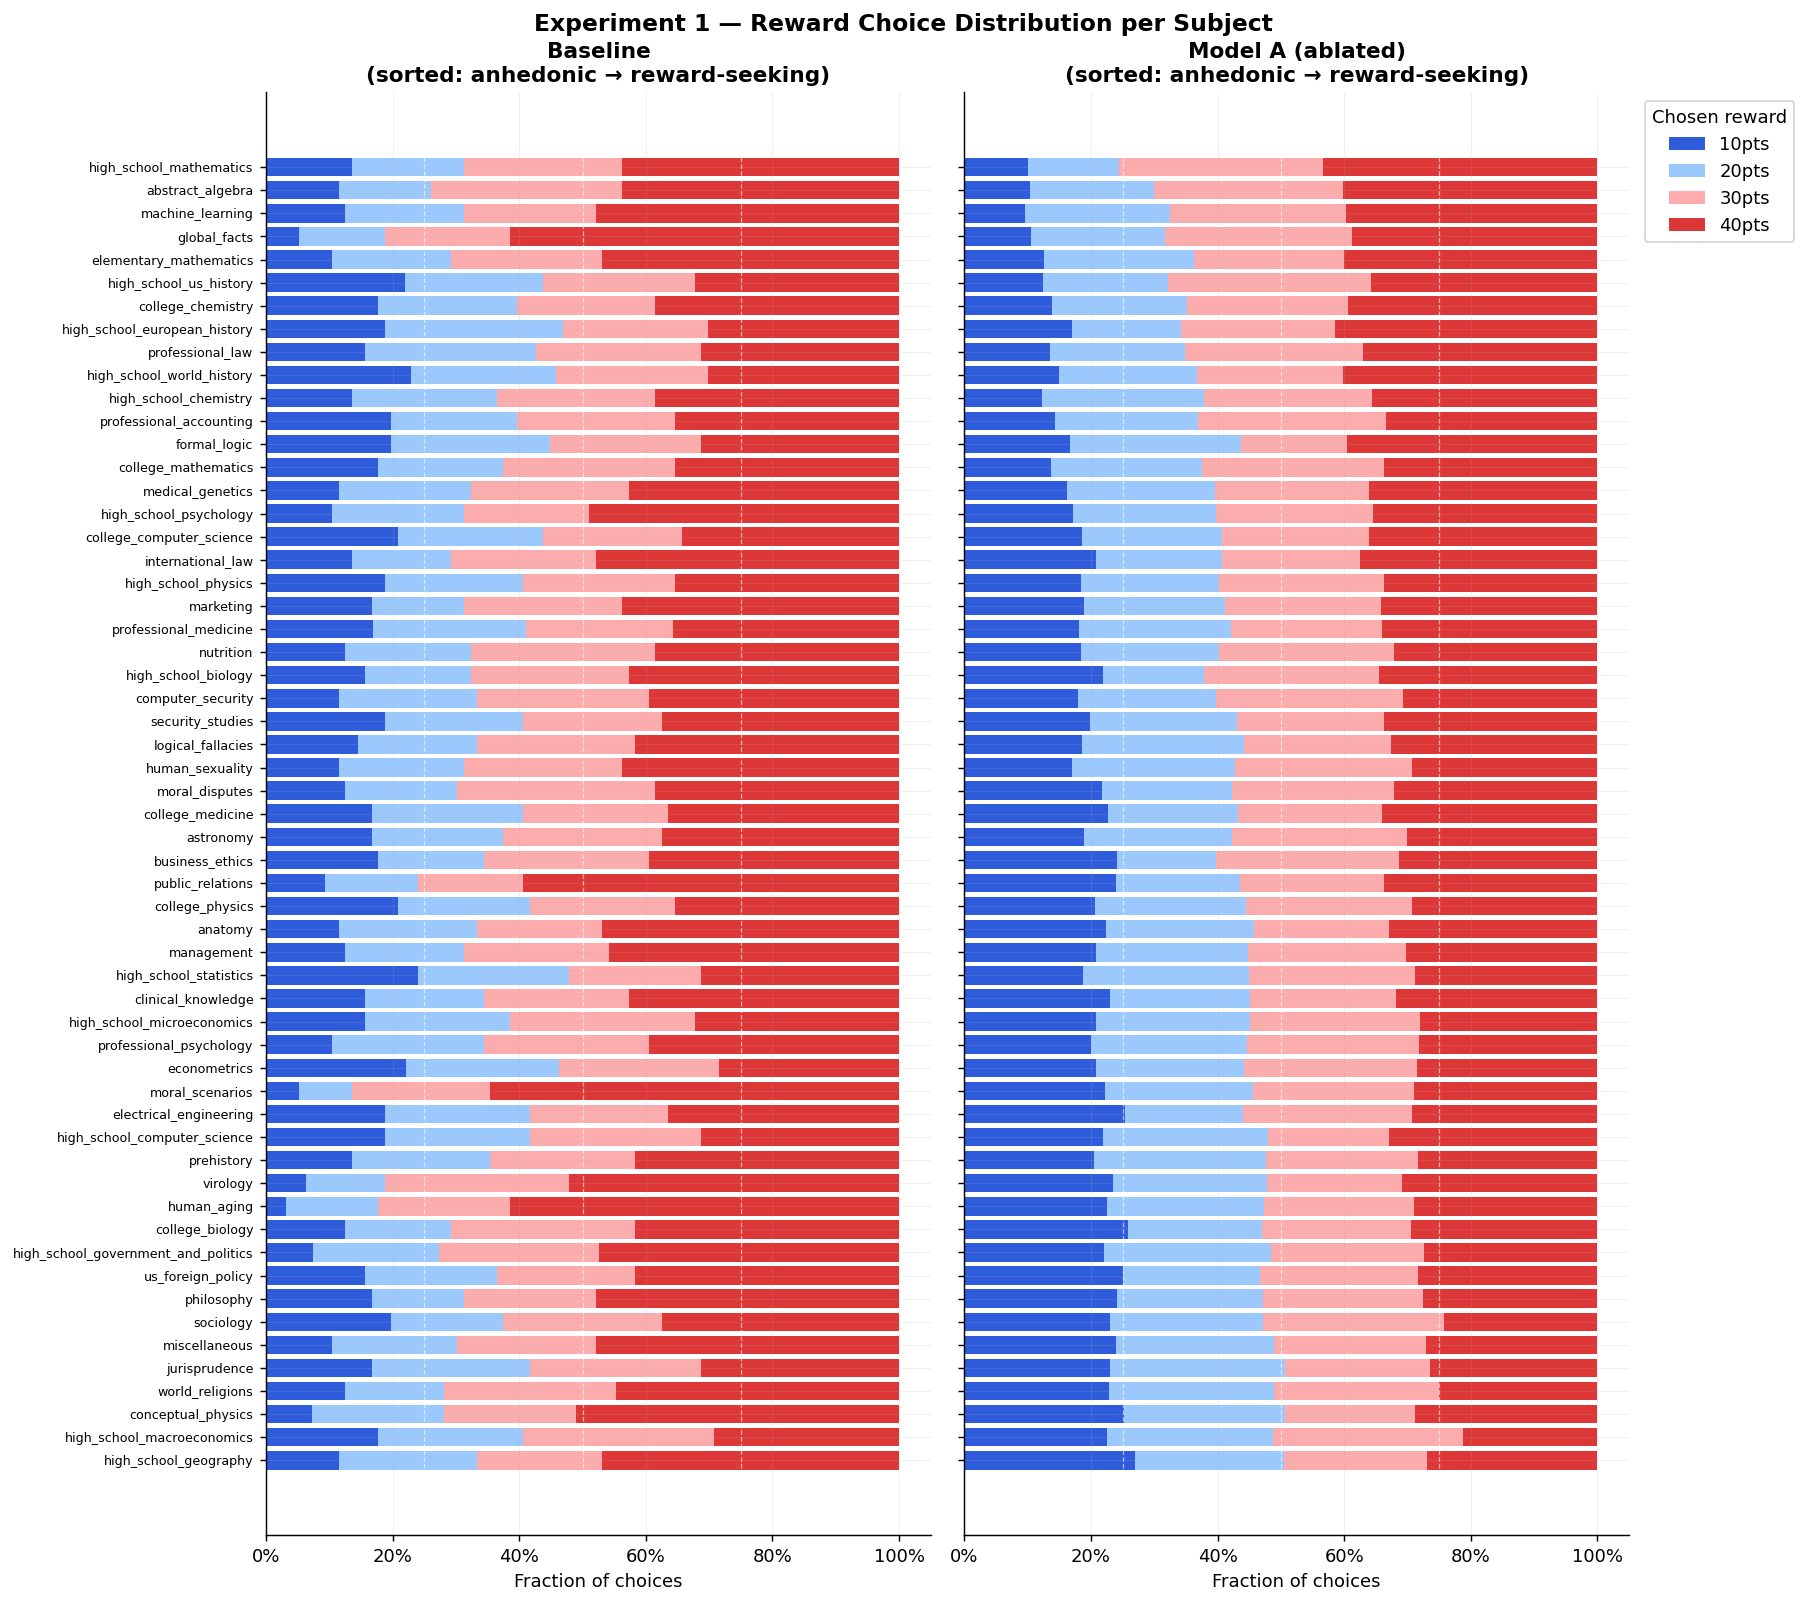

In [6]:
if not e1_raw.empty:
    fracs_b, fracs_a = {}, {}
    for subj, grp in e1_raw[e1_raw['tier']=='baseline'].groupby('subject'):
        v = grp['chosen_reward'].dropna()
        fracs_b[subj] = {r: (v==r).mean() for r in REWARD_LEVELS}
    for subj, grp in e1_raw[e1_raw['tier']=='model_A'].groupby('subject'):
        v = grp['chosen_reward'].dropna()
        fracs_a[subj] = {r: (v==r).mean() for r in REWARD_LEVELS}

    subj_order = pts.index.tolist()
    fb = pd.DataFrame(fracs_b).T.reindex(subj_order).fillna(0)
    fa = pd.DataFrame(fracs_a).T.reindex(subj_order).fillna(0)
    cmap = {10:C10, 20:C20, 30:C30, 40:C40}

    fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(subj_order)*0.22)), sharey=True)
    for ax, fdf, title in [(axes[0],fb,'Baseline'), (axes[1],fa,'Model A (ablated)')]:
        left = np.zeros(len(fdf))
        for r in REWARD_LEVELS:
            vals = fdf[r].values
            ax.barh(fdf.index, vals, left=left, color=cmap[r], label=f'{r}pts', alpha=0.92)
            left += vals
        for v in [0.25,0.5,0.75]:
            ax.axvline(v, color='white', lw=0.7, ls='--', alpha=0.6)
        ax.set_xlabel('Fraction of choices')
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.set_title(f'{title}\n(sorted: anhedonic → reward-seeking)', fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)
    axes[1].legend(title='Chosen reward', bbox_to_anchor=(1.01,1), loc='upper left')
    plt.suptitle('Experiment 1 — Reward Choice Distribution per Subject', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{EXP1_RESULTS}/fig_E1_stacked_per_subject.png', bbox_inches='tight')
    plt.show()

## E1.4 — 40pt choice rate per subject + error bars + p-value

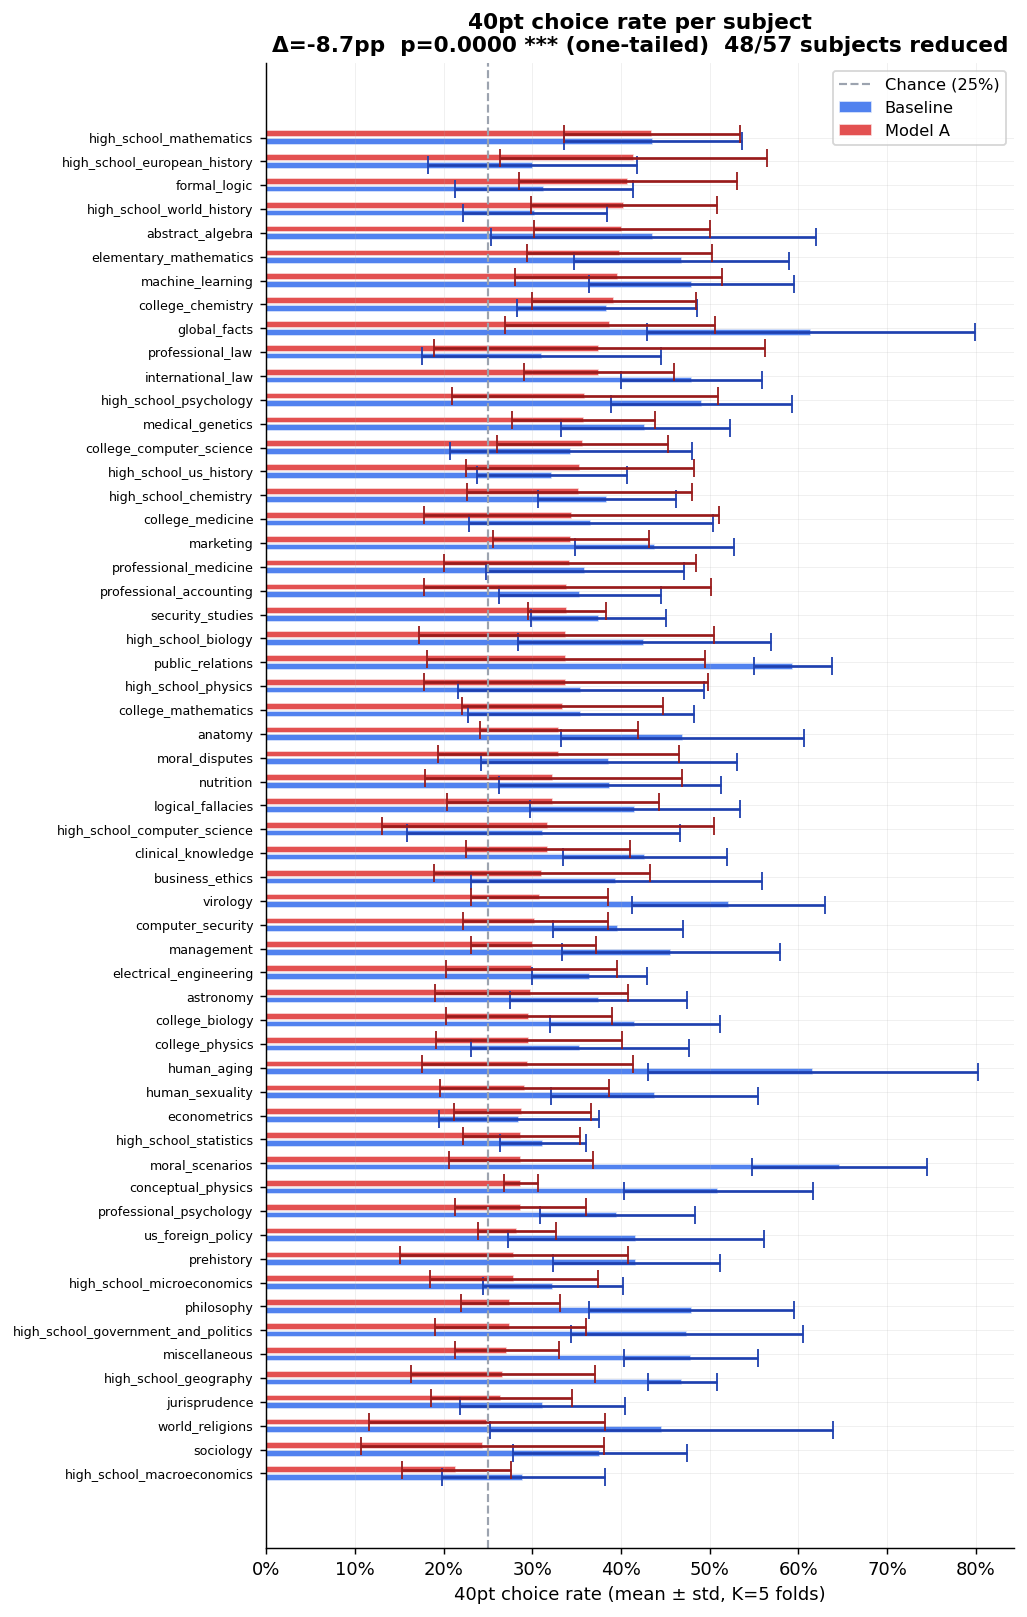

In [7]:
r40_b = e1_b.set_index('subject')[['rate_40pt_mean','rate_40pt_std']].rename(
    columns={'rate_40pt_mean':'mean','rate_40pt_std':'std'})
r40_a = e1_a.set_index('subject')[['rate_40pt_mean','rate_40pt_std']].rename(
    columns={'rate_40pt_mean':'mean','rate_40pt_std':'std'})
subj_order_40 = r40_a.sort_values('mean').index.tolist()
y = np.arange(len(subj_order_40))

fig, ax = plt.subplots(figsize=(8, max(6, len(subj_order_40)*0.22)))
ax.barh(y-0.16, r40_b.loc[subj_order_40,'mean'], 0.28,
        xerr=r40_b.loc[subj_order_40,'std'], color=BL, alpha=0.8, label='Baseline',
        edgecolor='white', error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#1e40af'})
ax.barh(y+0.16, r40_a.loc[subj_order_40,'mean'], 0.28,
        xerr=r40_a.loc[subj_order_40,'std'], color=MA, alpha=0.8, label='Model A',
        edgecolor='white', error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#991b1b'})
ax.axvline(CHANCE_RS, color=CH, lw=1.2, ls='--', label='Chance (25%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_yticks(y); ax.set_yticklabels(subj_order_40, fontsize=7)
ax.set_xlabel('40pt choice rate (mean ± std, K=5 folds)')
n_reduced = (r40_a['mean'] < r40_b['mean']).sum()
ax.set_title(f'40pt choice rate per subject\n'
             f'Δ={delta_40.mean()*100:+.1f}pp  p={p_40_1:.4f} {sig_stars(p_40_1)} (one-tailed)  '
             f'{n_reduced}/{len(r40_a)} subjects reduced',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{EXP1_RESULTS}/fig_E1_40pt_rate.png', bbox_inches='tight')
plt.show()

## E1.5 — Significance: per-subject t-test vs chance (BH-corrected)

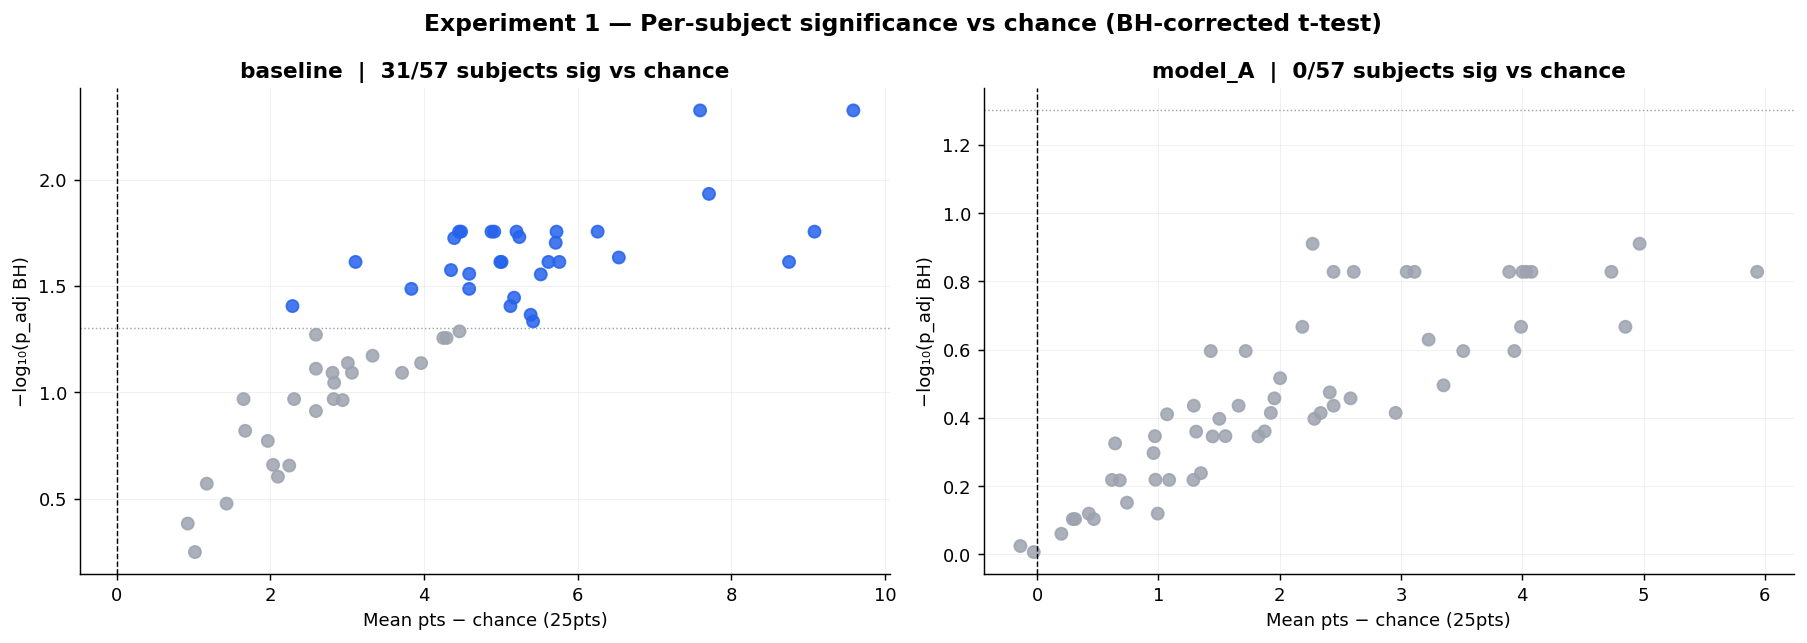

In [8]:
if not e1_subsets.empty:
    ttest_rows = []
    for (subj, tier), grp in e1_subsets.groupby(['subject','tier']):
        rr = grp['mean_pts'].values
        if len(rr) >= 2:
            t, p = sp_stats.ttest_1samp(rr, CHANCE_MEAN)
            ttest_rows.append({'subject':subj,'tier':tier,'t':t,'p':p,'mean':rr.mean()})
    ttest = pd.DataFrame(ttest_rows)
    for tier in ['baseline','model_A']:
        td = ttest[ttest['tier']==tier].copy()
        reject, p_adj, _, _ = multipletests(td['p'], method='fdr_bh')
        ttest.loc[td.index,'p_adj'] = p_adj
        ttest.loc[td.index,'sig']   = reject

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, tier, color in [(axes[0],'baseline',BL),(axes[1],'model_A',MA)]:
        td = ttest[ttest['tier']==tier]
        pt_colors = [color if s else CH for s in td['sig']]
        ax.scatter(td['mean']-CHANCE_MEAN, -np.log10(td['p_adj']),
                   c=pt_colors, s=45, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8, ls='--')
        ax.axhline(-np.log10(0.05), color=CH, lw=0.8, ls=':')
        ax.set_xlabel('Mean pts − chance (25pts)')
        ax.set_ylabel('−log₁₀(p_adj BH)')
        n_sig = td['sig'].sum()
        ax.set_title(f'{tier}  |  {n_sig}/{len(td)} subjects sig vs chance', fontweight='bold')
    plt.suptitle('Experiment 1 — Per-subject significance vs chance (BH-corrected t-test)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{EXP1_RESULTS}/fig_E1_significance.png', bbox_inches='tight')
    plt.show()

---
# EXPERIMENT 2 — Knowledge Integrity

## E2.1 — Accuracy per subject + error bars + p-value

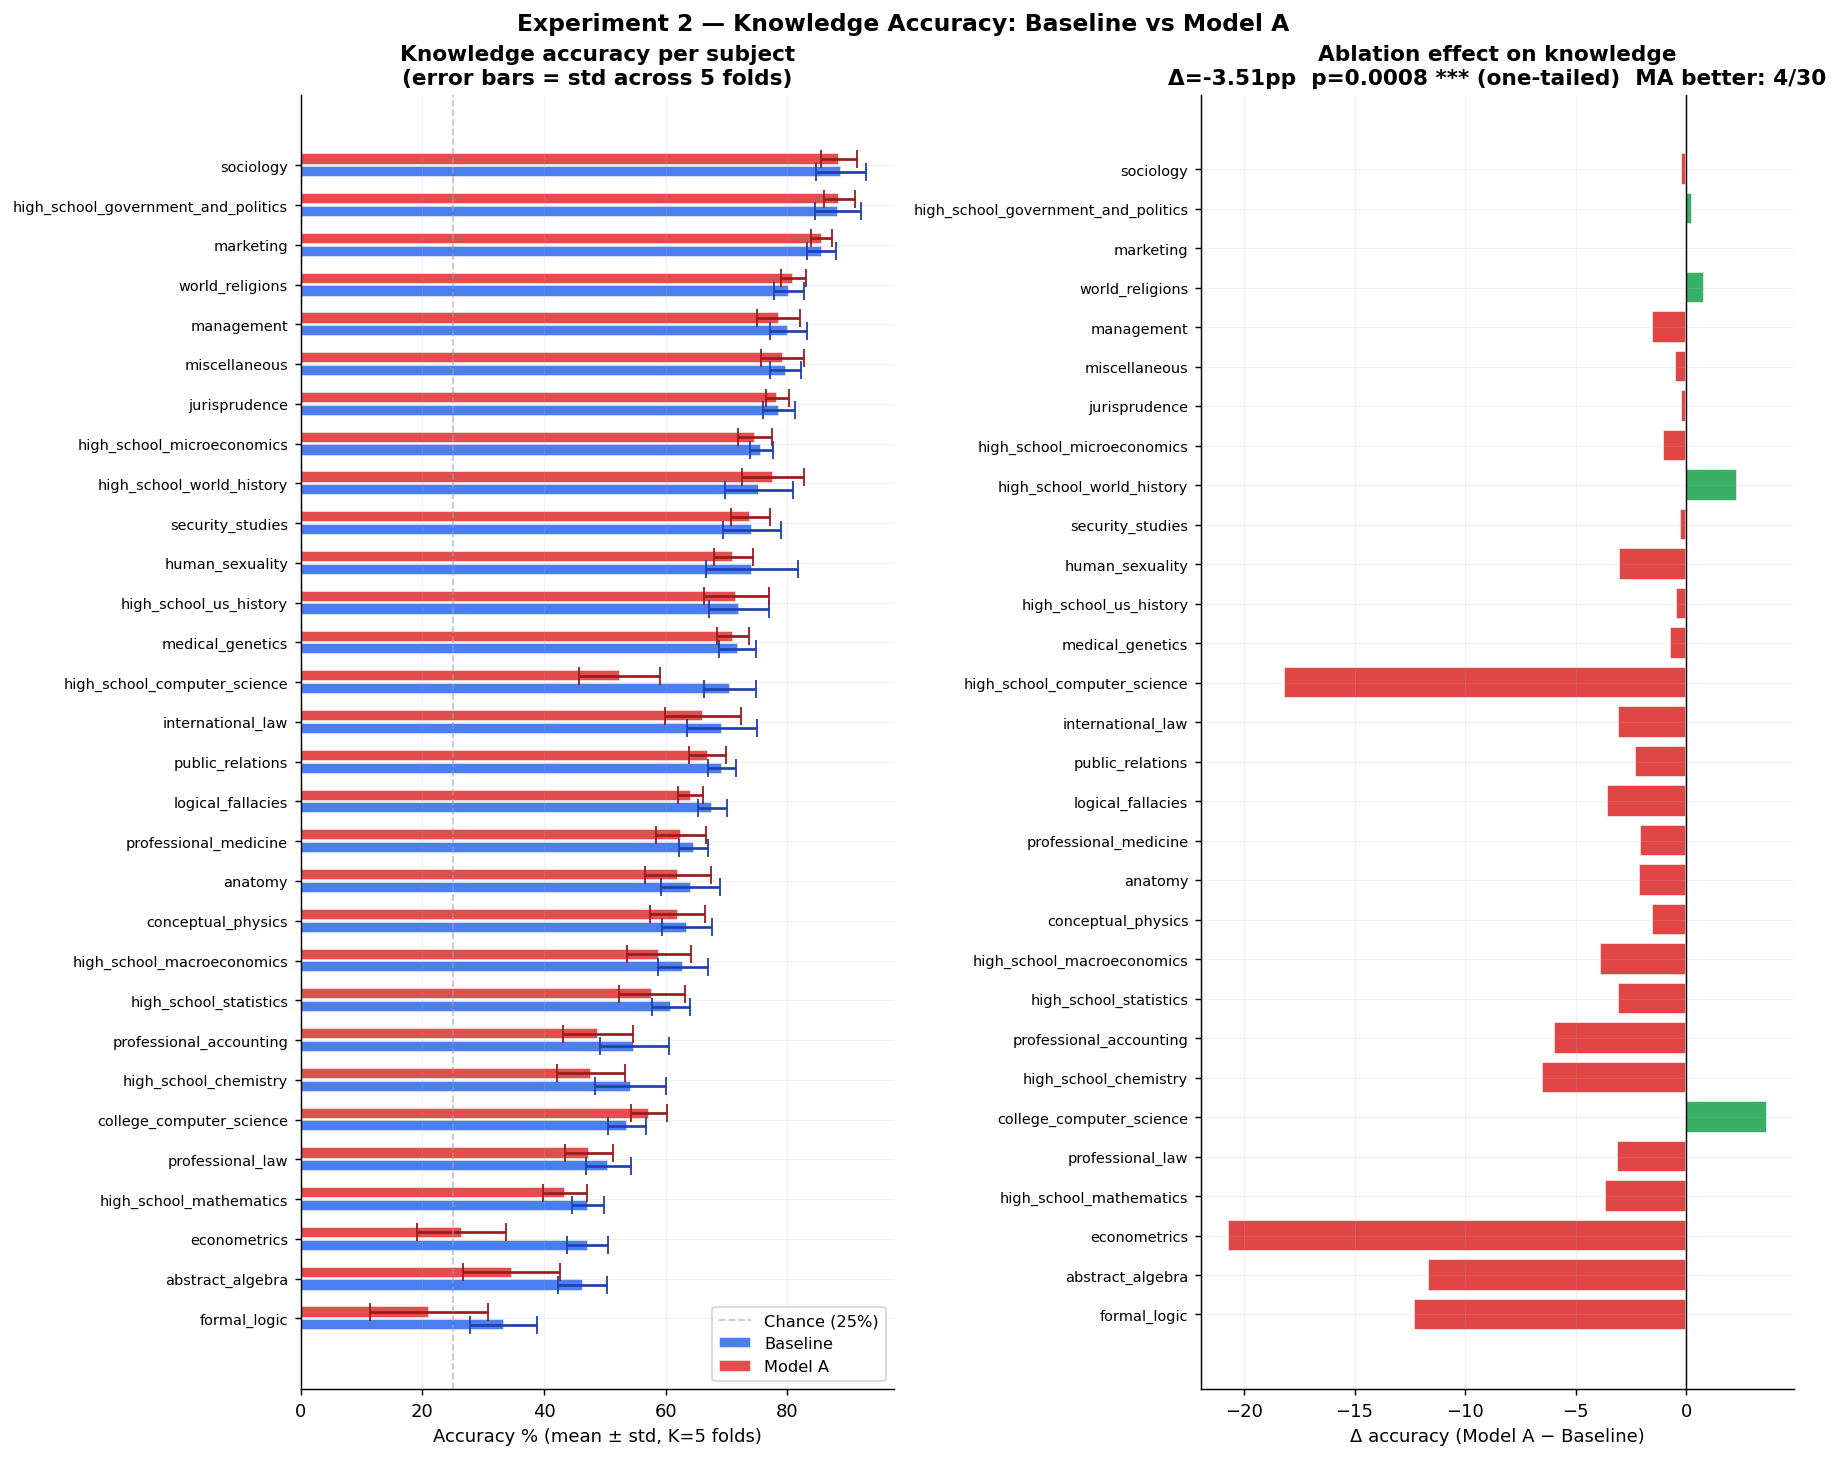

Grand mean: Baseline=66.84%  Model A=63.33%  Δ=-3.51pp  p=0.0008 ***


In [9]:
acc_b = e2_b.set_index('subject')[['acc_%_mean','acc_%_std']].copy()
acc_a = e2_a.set_index('subject')[['acc_%_mean','acc_%_std']].copy()
common = acc_b.index.intersection(acc_a.index)
acc_b, acc_a = acc_b.loc[common], acc_a.loc[common]
order = acc_b['acc_%_mean'].sort_values().index.tolist()
y = np.arange(len(order))

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(order)*0.38)))

ax = axes[0]
ax.barh(y-0.16, acc_b.loc[order,'acc_%_mean'], 0.28,
        xerr=acc_b.loc[order,'acc_%_std'], color=BL, alpha=0.82, label='Baseline',
        edgecolor='white', error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#1e40af'})
ax.barh(y+0.16, acc_a.loc[order,'acc_%_mean'], 0.28,
        xerr=acc_a.loc[order,'acc_%_std'], color=MA, alpha=0.82, label='Model A',
        edgecolor='white', error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#991b1b'})
ax.axvline(25, color=CH, lw=1, ls='--', alpha=0.6, label='Chance (25%)')
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel('Accuracy % (mean ± std, K=5 folds)')
ax.set_title('Knowledge accuracy per subject\n(error bars = std across 5 folds)', fontweight='bold')
ax.legend(fontsize=9)

ax2 = axes[1]
delta_acc_s = acc_a.loc[order,'acc_%_mean'] - acc_b.loc[order,'acc_%_mean']
dcols = [GR if d>=0 else MA for d in delta_acc_s]
ax2.barh(y, delta_acc_s, color=dcols, alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_yticks(y); ax2.set_yticklabels(order, fontsize=8)
ax2.set_xlabel('Δ accuracy (Model A − Baseline)')
n_better = (delta_acc_s>0).sum()
ax2.set_title(f'Ablation effect on knowledge\n'
              f'Δ={delta_acc.mean():+.2f}pp  p={p_acc1:.4f} {sig_stars(p_acc1)} (one-tailed)  '
              f'MA better: {n_better}/{len(delta_acc_s)}',
              fontweight='bold')

plt.suptitle('Experiment 2 — Knowledge Accuracy: Baseline vs Model A',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP2_RESULTS}/fig_E2_accuracy_per_subject.png', bbox_inches='tight')
plt.show()
print(f'Grand mean: Baseline={acc_b["acc_%_mean"].mean():.2f}%  Model A={acc_a["acc_%_mean"].mean():.2f}%  Δ={delta_acc.mean():+.2f}pp  p={p_acc1:.4f} {sig_stars(p_acc1)}')

## E2.2 — Accuracy by difficulty tier + error bars + p-values

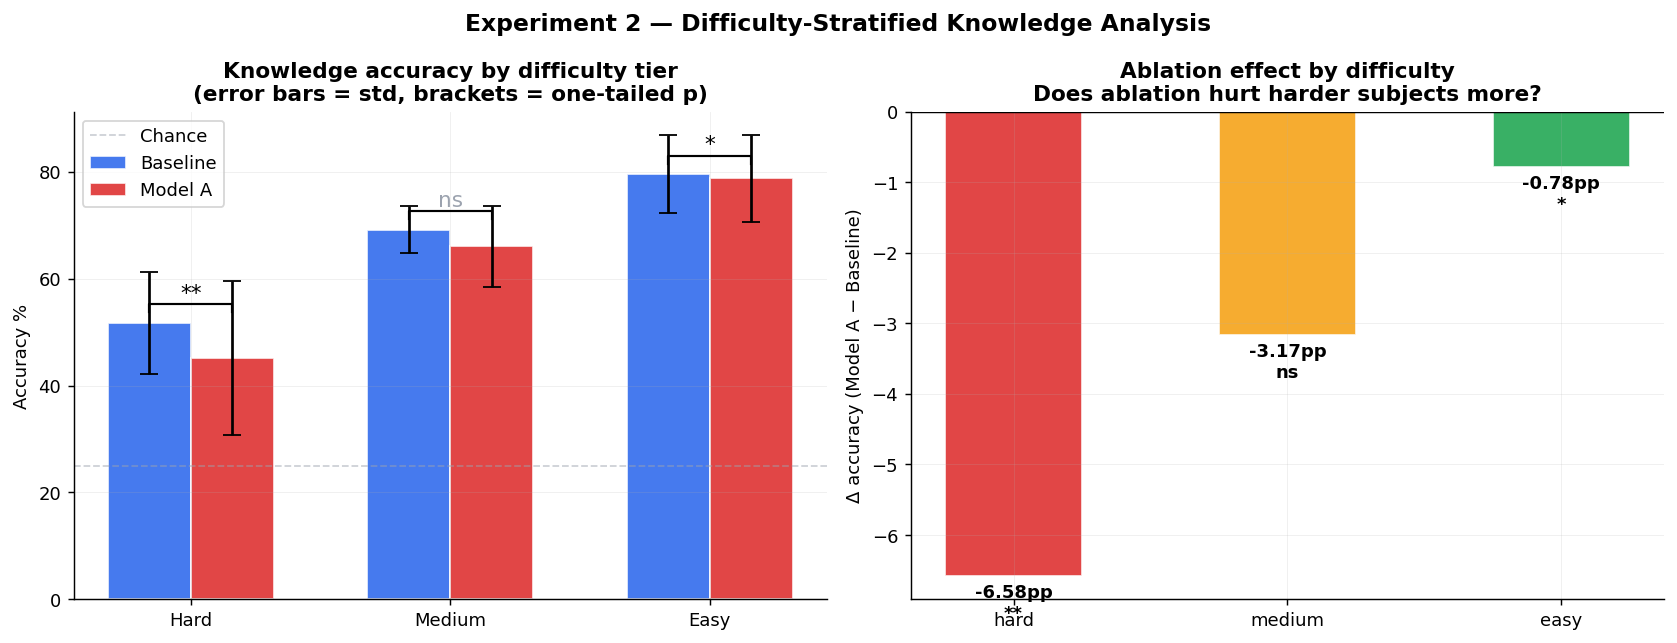

Δ accuracy by difficulty:
  hard    : -6.58pp  p=0.0067 **
  medium  : -3.17pp  p=0.0534 ns
  easy    : -0.78pp  p=0.0318 *


In [10]:
tiers_order = ['hard','medium','easy']
diff_colors = {'hard':'#DC2626','medium':'#F59E0B','easy':'#16A34A'}
x = np.arange(3); w = 0.32

b_means = [e2_b[e2_b['difficulty_tier']==d]['acc_%_mean'].mean() for d in tiers_order]
a_means = [e2_a[e2_a['difficulty_tier']==d]['acc_%_mean'].mean() for d in tiers_order]
b_stds  = [e2_b[e2_b['difficulty_tier']==d]['acc_%_mean'].std()  for d in tiers_order]
a_stds  = [e2_a[e2_a['difficulty_tier']==d]['acc_%_mean'].std()  for d in tiers_order]

# Per-tier paired t-tests
tier_pvals = []
for d in tiers_order:
    bd = e2_b[e2_b['difficulty_tier']==d].set_index('subject')['acc_%_mean']
    ad = e2_a[e2_a['difficulty_tier']==d].set_index('subject')['acc_%_mean']
    common_d = bd.index.intersection(ad.index)
    if len(common_d) >= 2:
        _, p = sp_stats.ttest_rel(ad.loc[common_d].values, bd.loc[common_d].values, alternative='less')
    else:
        p = 1.0
    tier_pvals.append(p)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.bar(x-w/2, b_means, w, yerr=b_stds, label='Baseline', color=BL, alpha=0.85,
       error_kw={'elinewidth':1.5,'capsize':5}, edgecolor='white')
ax.bar(x+w/2, a_means, w, yerr=a_stds, label='Model A',  color=MA, alpha=0.85,
       error_kw={'elinewidth':1.5,'capsize':5}, edgecolor='white')
ax.axhline(25, color=CH, lw=1, ls='--', alpha=0.5, label='Chance')
# Add significance brackets per tier
for i, (p_t, bm, am) in enumerate(zip(tier_pvals, b_means, a_means)):
    add_sig_bracket(ax, i-w/2, i+w/2, max(bm,am)+2, p_t, h=1.5, fs=12)
ax.set_xticks(x); ax.set_xticklabels(['Hard','Medium','Easy'])
ax.set_ylabel('Accuracy %')
ax.set_title('Knowledge accuracy by difficulty tier\n(error bars = std, brackets = one-tailed p)', fontweight='bold')
ax.legend()

ax2 = axes[1]
deltas = [a-b for a,b in zip(a_means, b_means)]
d_colors = [diff_colors[t] for t in tiers_order]
bars = ax2.bar(tiers_order, deltas, color=d_colors, alpha=0.85, edgecolor='white', width=0.5)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Δ accuracy (Model A − Baseline)')
ax2.set_title('Ablation effect by difficulty\nDoes ablation hurt harder subjects more?', fontweight='bold')
for bar, d, p_t in zip(bars, deltas, tier_pvals):
    y_pos = d + (0.3 if d>=0 else -0.6)
    ax2.text(bar.get_x()+bar.get_width()/2, y_pos,
             f'{d:+.2f}pp\n{sig_stars(p_t)}',
             ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Experiment 2 — Difficulty-Stratified Knowledge Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP2_RESULTS}/fig_E2_accuracy_by_difficulty.png', bbox_inches='tight')
plt.show()
print('Δ accuracy by difficulty:')
for d, delta_d, p_t in zip(tiers_order, deltas, tier_pvals):
    print(f'  {d:<8}: {delta_d:+.2f}pp  p={p_t:.4f} {sig_stars(p_t)}')

## E2.3 — Per-question accuracy + error bars

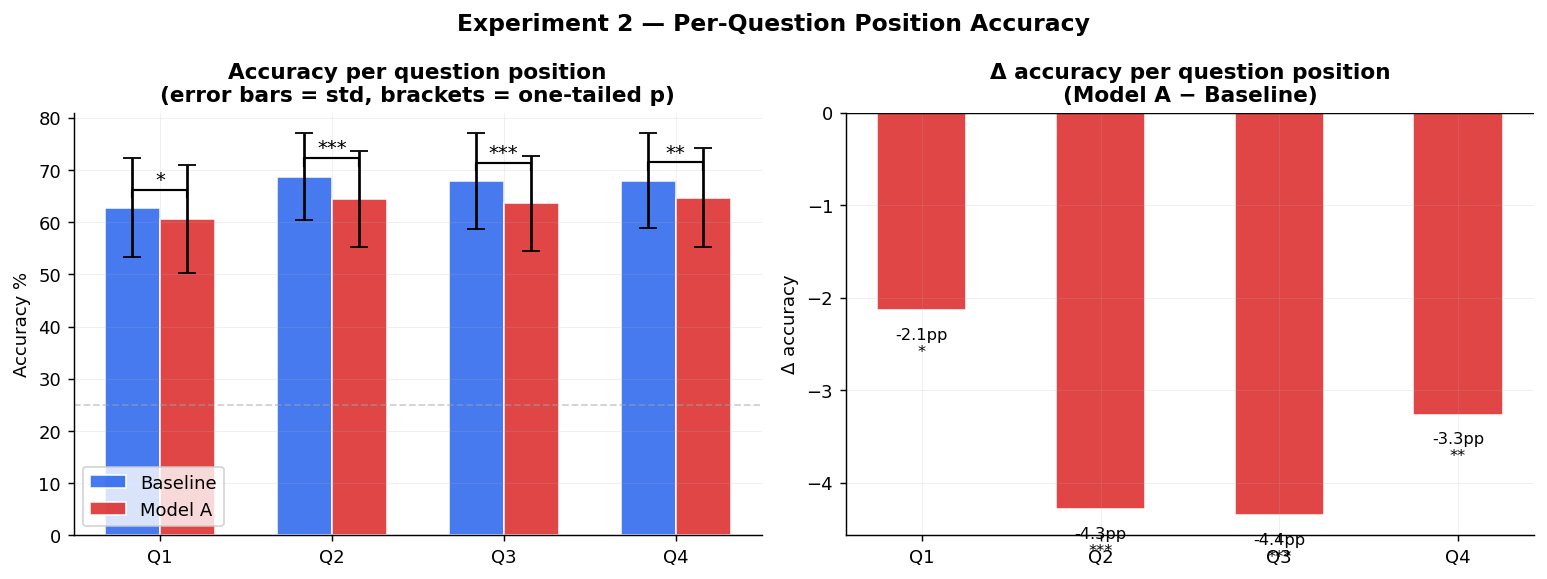

In [11]:
q_cols = ['acc_q1_%_mean','acc_q2_%_mean','acc_q3_%_mean','acc_q4_%_mean']
q_stds = ['acc_q1_%_std', 'acc_q2_%_std', 'acc_q3_%_std', 'acc_q4_%_std']
q_b = e2_b[q_cols+q_stds].mean()
q_a = e2_a[q_cols+q_stds].mean()
x = np.arange(4); w = 0.32

# Per-question paired t-test
q_pvals = []
for col in q_cols:
    bq = e2_b.set_index('subject')[col]
    aq = e2_a.set_index('subject')[col]
    cq = bq.index.intersection(aq.index)
    _, p = sp_stats.ttest_rel(aq.loc[cq].values, bq.loc[cq].values, alternative='less')
    q_pvals.append(p)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.bar(x-w/2, [q_b[c] for c in q_cols], w, label='Baseline',
       yerr=[q_b[s] for s in q_stds], color=BL, alpha=0.85, edgecolor='white',
       error_kw={'elinewidth':1.5,'capsize':5})
ax.bar(x+w/2, [q_a[c] for c in q_cols], w, label='Model A',
       yerr=[q_a[s] for s in q_stds], color=MA, alpha=0.85, edgecolor='white',
       error_kw={'elinewidth':1.5,'capsize':5})
ax.axhline(25, color=CH, lw=1, ls='--', alpha=0.5)
for i, p_q in enumerate(q_pvals):
    add_sig_bracket(ax, i-w/2, i+w/2, max(q_b[q_cols[i]], q_a[q_cols[i]])+2, p_q, h=1.5, fs=11)
ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
ax.set_ylabel('Accuracy %')
ax.set_title('Accuracy per question position\n(error bars = std, brackets = one-tailed p)', fontweight='bold')
ax.legend()

ax2 = axes[1]
deltas_q = [q_a[c]-q_b[c] for c in q_cols]
dc = [GR if d>=0 else MA for d in deltas_q]
ax2.bar(['Q1','Q2','Q3','Q4'], deltas_q, color=dc, alpha=0.85, edgecolor='white', width=0.5)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Δ accuracy')
ax2.set_title('Δ accuracy per question position\n(Model A − Baseline)', fontweight='bold')
for i, (d, p_q) in enumerate(zip(deltas_q, q_pvals)):
    ax2.text(i, d+(0.3 if d>=0 else -0.5), f'{d:+.1f}pp\n{sig_stars(p_q)}',
             ha='center', fontsize=9)

plt.suptitle('Experiment 2 — Per-Question Position Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP2_RESULTS}/fig_E2_per_question.png', bbox_inches='tight')
plt.show()

## E2.4 — K=5 fold stability

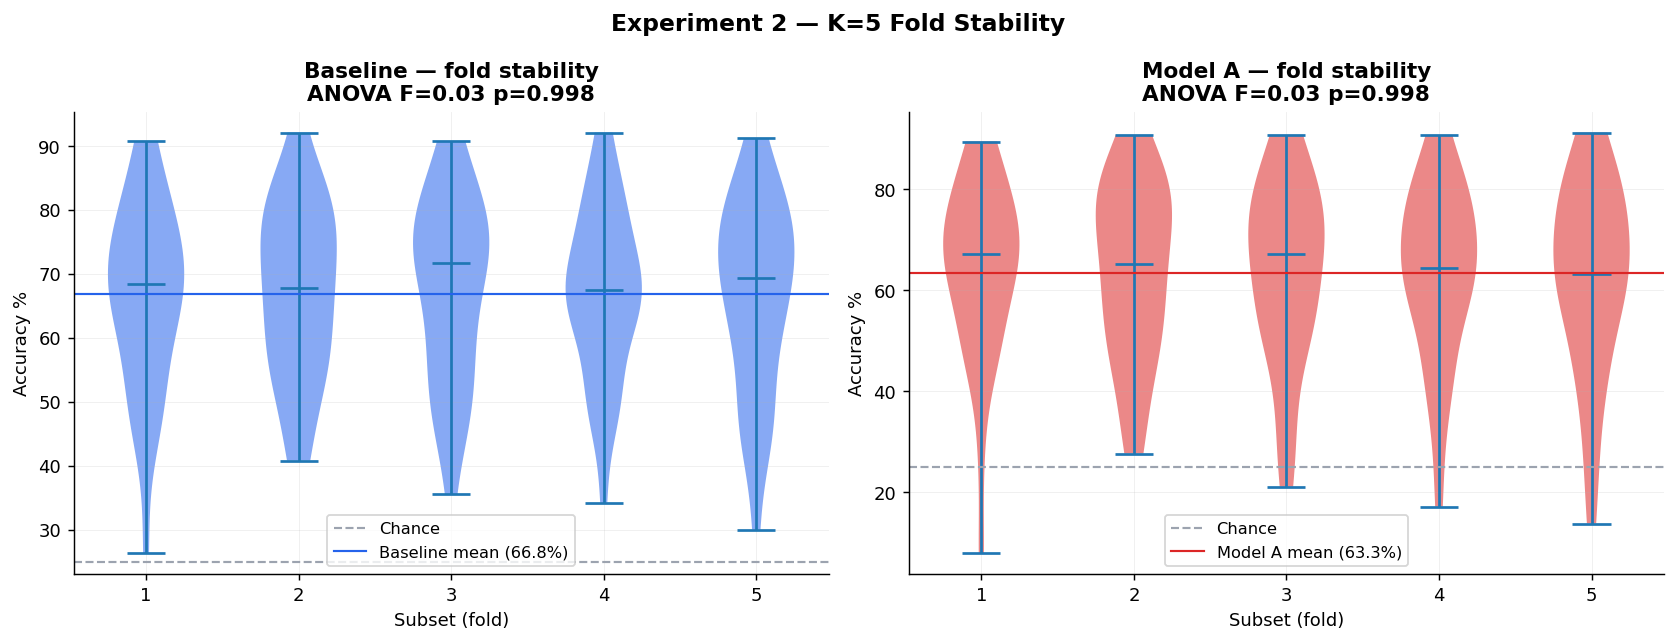

In [12]:
if not e2_subsets.empty:
    fold_ids = sorted(e2_subsets['subset'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, tier, color, label in [
        (axes[0],'baseline',BL,'Baseline'),(axes[1],'model_A',MA,'Model A')]:
        td = e2_subsets[e2_subsets['tier']==tier]
        fold_data = [td[td['subset']==k]['acc_%'].dropna().values for k in fold_ids]
        vp = ax.violinplot(fold_data, positions=fold_ids, showmedians=True)
        for body in vp['bodies']:
            body.set_facecolor(color); body.set_alpha(0.55)
        gm = td['acc_%'].mean()
        ax.axhline(25, color=CH, lw=1.2, ls='--', label='Chance')
        ax.axhline(gm, color=color, lw=1.2, ls='-', label=f'{label} mean ({gm:.1f}%)')
        f_stat, p_anova = sp_stats.f_oneway(*fold_data)
        ax.set_xticks(fold_ids); ax.set_xlabel('Subset (fold)')
        ax.set_ylabel('Accuracy %')
        ax.set_title(f'{label} — fold stability\nANOVA F={f_stat:.2f} p={p_anova:.3f}',
                     fontweight='bold')
        ax.legend(fontsize=9)
    plt.suptitle('Experiment 2 — K=5 Fold Stability', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{EXP2_RESULTS}/fig_E2_fold_stability.png', bbox_inches='tight')
    plt.show()

---
# COMBINED SUMMARY — Both Experiments

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
cats = ['Baseline','Model A','Chance']
cols_pts = [BL, MA, CH]

# ── Panel 1: Mean pts ──────────────────────────────────────────────────────
ax = axes[0]
means_pts = [e1_b['mean_pts_mean'].mean(), e1_a['mean_pts_mean'].mean(), CHANCE_MEAN]
stds_pts  = [e1_b['mean_pts_std'].mean(),  e1_a['mean_pts_std'].mean(),  0]
bars = ax.bar(cats, means_pts, yerr=stds_pts, color=cols_pts, alpha=0.85,
              edgecolor='white', width=0.5, error_kw={'elinewidth':1.5,'capsize':6})
ax.axhline(CHANCE_MEAN, color=CH, lw=1, ls='--', alpha=0.5)
ax.set_ylim(0, 40)
ax.set_ylabel('Mean points chosen')
for bar, val in zip(bars, means_pts):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.4, f'{val:.1f}', ha='center', fontweight='bold')
add_sig_bracket(ax, 0, 1, max(means_pts[:2])+2, p_pts1, h=0.8, fs=13)
ax.set_title(f'Exp1: Mean pts chosen\nΔ={delta_pts.mean():+.2f}  {sig_stars(p_pts1)} (one-tailed p={p_pts1:.4f})',
             fontweight='bold')

# ── Panel 2: 40pt rate ─────────────────────────────────────────────────────
ax2 = axes[1]
r40_means = [e1_b['rate_40pt_mean'].mean(), e1_a['rate_40pt_mean'].mean(), CHANCE_RS]
r40_stds  = [e1_b['rate_40pt_std'].mean(),  e1_a['rate_40pt_std'].mean(),  0]
bars2 = ax2.bar(cats, r40_means, yerr=r40_stds, color=cols_pts, alpha=0.85,
                edgecolor='white', width=0.5, error_kw={'elinewidth':1.5,'capsize':6})
ax2.axhline(CHANCE_RS, color=CH, lw=1, ls='--', alpha=0.5)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel('40pt choice rate')
for bar, val in zip(bars2, r40_means):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.1%}', ha='center', fontweight='bold')
add_sig_bracket(ax2, 0, 1, max(r40_means[:2])+0.025, p_40_1, h=0.01, fs=13)
ax2.set_title(f'Exp1: 40pt choice rate\nΔ={delta_40.mean()*100:+.1f}pp  {sig_stars(p_40_1)} (one-tailed p={p_40_1:.4f})',
              fontweight='bold')

# ── Panel 3: Knowledge accuracy ────────────────────────────────────────────
ax3 = axes[2]
acc_means = [e2_b['acc_%_mean'].mean(), e2_a['acc_%_mean'].mean(), 25.0]
acc_stds  = [e2_b['acc_%_std'].mean(),  e2_a['acc_%_std'].mean(),  0]
bars3 = ax3.bar(cats, acc_means, yerr=acc_stds, color=cols_pts, alpha=0.85,
                edgecolor='white', width=0.5, error_kw={'elinewidth':1.5,'capsize':6})
ax3.axhline(25, color=CH, lw=1, ls='--', alpha=0.5)
ax3.set_ylim(0, 90)
ax3.set_ylabel('Accuracy %')
for bar, val in zip(bars3, acc_means):
    ax3.text(bar.get_x()+bar.get_width()/2, val+0.8, f'{val:.1f}%', ha='center', fontweight='bold')
add_sig_bracket(ax3, 0, 1, max(acc_means[:2])+4, p_acc1, h=2, fs=13)
ax3.set_title(f'Exp2: Knowledge accuracy\nΔ={delta_acc.mean():+.2f}pp  {sig_stars(p_acc1)} (one-tailed p={p_acc1:.4f})',
              fontweight='bold')

plt.suptitle('Anhedonic AI — Combined Summary\n'
             'Ablation attenuates reward-seeking while largely preserving knowledge',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{EXP1_RESULTS}/fig_COMBINED_summary.png', bbox_inches='tight')
plt.show()

print('=== COMBINED FINAL SUMMARY ===')
print(f'Exp1 Mean pts : Baseline={e1_b["mean_pts_mean"].mean():.2f}  ModelA={e1_a["mean_pts_mean"].mean():.2f}  Δ={delta_pts.mean():+.3f}  p={p_pts1:.4f} {sig_stars(p_pts1)}')
print(f'Exp1 40pt rate: Baseline={e1_b["rate_40pt_mean"].mean():.3f}  ModelA={e1_a["rate_40pt_mean"].mean():.3f}  Δ={delta_40.mean()*100:+.2f}pp  p={p_40_1:.4f} {sig_stars(p_40_1)}')
print(f'Exp2 Accuracy : Baseline={e2_b["acc_%_mean"].mean():.2f}%  ModelA={e2_a["acc_%_mean"].mean():.2f}%  Δ={delta_acc.mean():+.2f}pp  p={p_acc1:.4f} {sig_stars(p_acc1)}')
print(f'\n95% CIs:')
print(f'  Mean pts  : [{ci_pts[0]:.3f}, {ci_pts[1]:.3f}]')
print(f'  40pt rate : [{ci_40[0]*100:.2f}pp, {ci_40[1]*100:.2f}pp]')
print(f'  Accuracy  : [{ci_acc[0]:.2f}pp, {ci_acc[1]:.2f}pp]')